# 1. 측정 복원 결과 점검
스크립트 산출물만 읽습니다. 설계 그림은 2021-08-31까지이며 9월 목표는 분석하지 않습니다.

In [1]:
from pathlib import Path
import os
from datetime import date
import json
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams['font.family'] = 'NanumSquare'
plt.rcParams['axes.unicode_minus'] = False
DATA = Path('../5. 자원 최적화 AI 데이터셋')
RESULTS = Path(os.environ.get('KAMP_RESULTS', os.environ.get('GMST_RESULTS', '../results')))
df = pl.read_csv(DATA / 'okm_15min_2021.csv').with_columns(pl.col('datetime').str.strptime(pl.Datetime, '%Y.%m.%d %H:%M:%S'))
df = df.with_columns(pl.col('datetime').dt.date().alias('date'), (pl.col('datetime').dt.hour() * 4 + pl.col('datetime').dt.minute() // 15).alias('quarter'))
audit = json.loads((RESULTS / 'data_audit.json').read_text())
assert df.height == 24672
assert df.group_by('date').len()['len'].eq(96).all()
assert df['datetime'].diff().drop_nulls().dt.total_minutes().eq(15).all()
assert df['is_missing'].sum() == audit['zero_points'] == 74
print(f"감사: zero_points={audit['zero_points']}, wind_null_hours={audit['wind_null_hours']}, precip_null_hours={audit['precip_null_hours']}")
df = df.filter(pl.col('date') <= date(2021, 8, 31))
display(df.head())


감사: zero_points=74, wind_null_hours=3, precip_null_hours=1


datetime,전력,생산량,기온,풍속,습도,강수량_증분,전기요금(계절),인건비,is_missing,date,quarter
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,bool,date,i8
2021-01-01 00:00:00,62.0,0.0,-3.2,2.4,71.0,0.0,109.8,1.5,false,2021-01-01,0
2021-01-01 00:15:00,61.0,0.0,-3.2,2.4,71.0,0.0,109.8,1.5,false,2021-01-01,1
2021-01-01 00:30:00,61.0,0.0,-3.2,2.4,71.0,0.0,109.8,1.5,false,2021-01-01,2
2021-01-01 00:45:00,61.0,0.0,-3.2,2.4,71.0,0.0,109.8,1.5,false,2021-01-01,3
2021-01-01 01:00:00,96.0,0.0,-4.5,1.5,77.0,0.0,109.8,1.5,false,2021-01-01,4


## 시계열과 날짜 × 슬롯

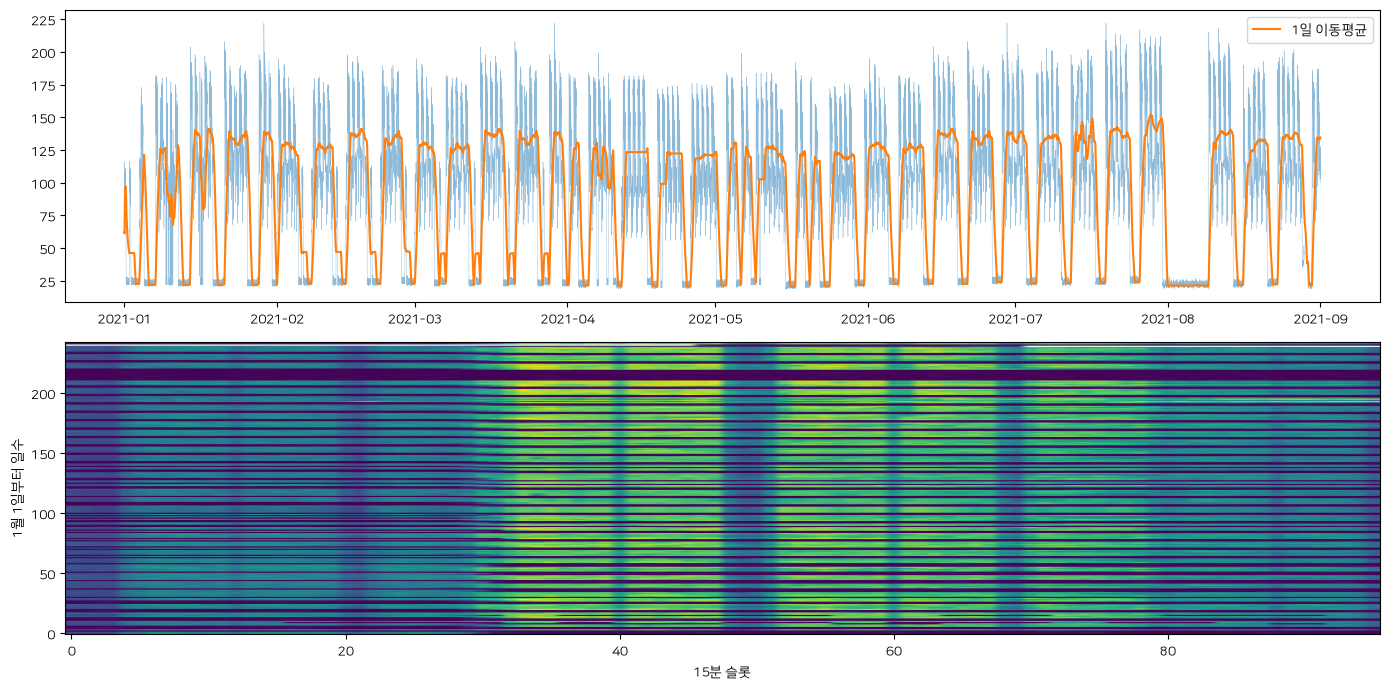

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(df['datetime'], df['전력'], linewidth=.3, alpha=.5)
axes[0].plot(df['datetime'], df['전력'].rolling_mean(96, min_samples=1), label='1일 이동평균')
axes[0].legend()
axes[1].imshow(df['전력'].to_numpy().reshape(-1, 96), aspect='auto', origin='lower')
axes[1].set(xlabel='15분 슬롯', ylabel='1월 1일부터 일수')
plt.tight_layout()
plt.show()


## 평일·주말 프로파일, 분포, 생산·기온 관계

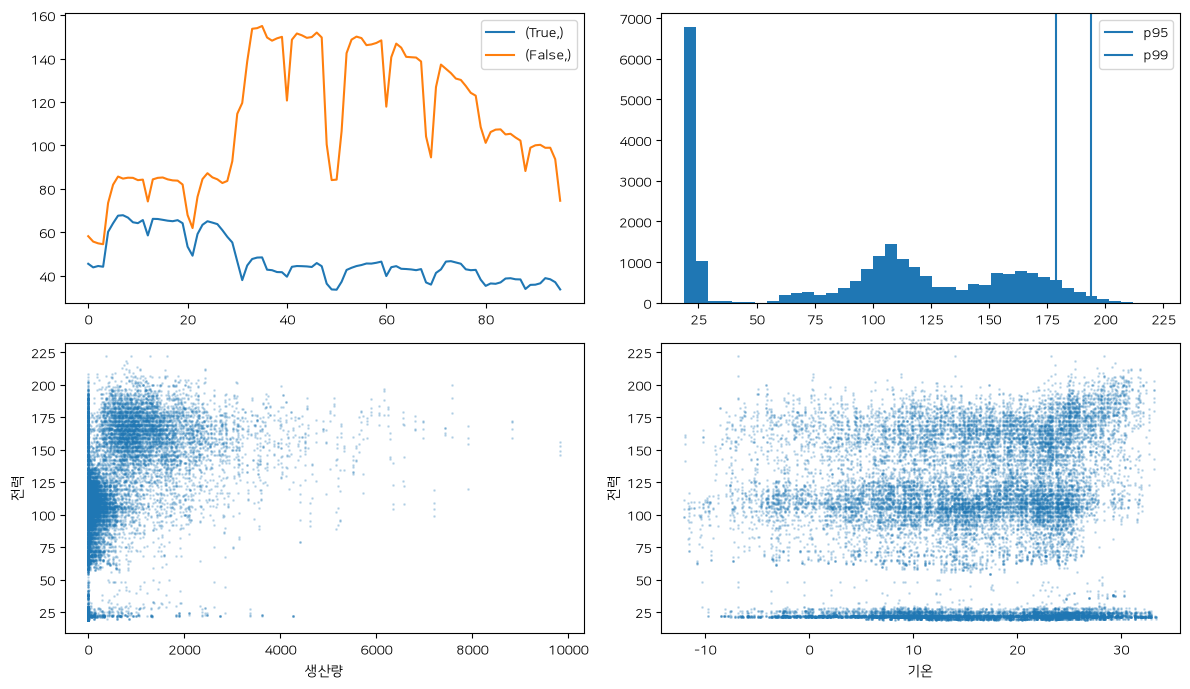

In [3]:
profile = df.with_columns((pl.col('datetime').dt.weekday() >= 6).alias('weekend')).group_by('weekend', 'quarter').agg(pl.col('전력').mean()).sort('quarter')
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for weekend, group in profile.group_by('weekend'):
    axes[0, 0].plot(group['quarter'], group['전력'], label=str(weekend))
axes[0, 0].legend()
axes[0, 1].hist(df['전력'].drop_nulls(), bins=40)
for q in (.95, .99):
    axes[0, 1].axvline(df['전력'].quantile(q), label=f'p{q*100:g}')
axes[0, 1].legend()
for ax, x in zip(axes[1], ('생산량', '기온')):
    ax.scatter(df[x], df['전력'], s=1, alpha=.2)
    ax.set(xlabel=x, ylabel='전력')
plt.tight_layout()
plt.show()
